### **Linear Regression for Telco dataset**

#### **Importing Libraries**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

#### **Loading Dataset**

In [14]:
df = pd.read_csv(
    "D:/261100670031/APS_LAB/Dataset/Telco-Customer-Churn.csv"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (7043, 21)


#### **Inspecting Dataset**

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null 

In [16]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [17]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


In [18]:
print("\nData Types:")
print(df.dtypes)


Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


#### **Data Cleaning**

In [3]:
df_clean = df.drop(
    columns=["customerID"]
).copy()

print("customerID removed.")
print("Shape:", df_clean.shape)

customerID removed.
Shape: (7043, 20)


In [4]:
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

print(
    "Missing TotalCharges after conversion:",
    df_clean["TotalCharges"].isnull().sum()
)

Missing TotalCharges after conversion: 11


In [5]:
df_clean = df_clean.dropna(
    subset=["TotalCharges"]
)

print(
    "Missing TotalCharges after cleaning:",
    df_clean["TotalCharges"].isnull().sum()
)

print(
    "Shape after removing missing values:",
    df_clean.shape
)

Missing TotalCharges after cleaning: 0
Shape after removing missing values: (7032, 20)


In [6]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates()

after = len(df_clean)

print(
    "Duplicates removed:",
    before - after
)

print(
    "Final cleaned shape:",
    df_clean.shape
)

Duplicates removed: 22
Final cleaned shape: (7010, 20)


In [14]:
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
print("\nFinal Missing Values:")
print(df_clean.isnull().sum().sum())

print("\nFinal Duplicate Count:")
print(df_clean.duplicated().sum())


Final Missing Values:
0

Final Duplicate Count:
0


#### **Feature Selection**

In [7]:
X = df_clean[
    [
        "tenure",
        "MonthlyCharges"
    ]
]

y = df_clean["TotalCharges"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   tenure  MonthlyCharges
0       1           29.85
1      34           56.95
2       2           53.85
3      45           42.30
4       2           70.70

Target:
0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64


In [17]:
print("Features used:")
print(X.columns.tolist())

print("\nTarget variable:")
print("TotalCharges")

print("\nFeature shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

Features used:
['tenure', 'MonthlyCharges']

Target variable:
TotalCharges

Feature shape:
(7010, 2)

Target shape:
(7010,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5608
Testing samples: 1402


#### **Linear Regression**

In [9]:
model = LinearRegression()

print("Linear Regression model created.")

Linear Regression model created.


In [20]:
model.fit(
    X_train,
    y_train
)

print(
    "Linear Regression model trained successfully."
)
y_pred = model.predict(X_test)
y_pred

Linear Regression model trained successfully.


array([6061.6953425 ,  399.65451571,  785.97429244, ..., 1482.97953434,
       5643.04824425, 2829.11639394], shape=(1402,))

In [21]:
print(
    "Intercept:",
    model.intercept_
)

print(
    "Tenure coefficient:",
    model.coef_[0]
)

print(
    "MonthlyCharges coefficient:",
    model.coef_[1]
)

Intercept: -2173.242687242351
Tenure coefficient: 65.76452582997302
MonthlyCharges coefficient: 35.781803269602804


In [22]:
print("Regression Equation:")

print(
    f"TotalCharges = "
    f"{model.intercept_:.2f} "
    f"+ ({model.coef_[0]:.2f} × tenure) "
    f"+ ({model.coef_[1]:.2f} × MonthlyCharges)"
)

Regression Equation:
TotalCharges = -2173.24 + (65.76 × tenure) + (35.78 × MonthlyCharges)


#### **Prediction**

In [11]:
y_pred = model.predict(
    X_test
)

print("Predictions generated successfully.")
print(y_pred[:10])

Predictions generated successfully.
[6061.6953425   399.65451571  785.97429244 -139.72524394  851.30814285
 3887.88780979 1432.76131118 6648.51691612 5876.98724544  561.16628993]


In [24]:
prediction_table = pd.DataFrame({
    "Actual TotalCharges": y_test.values,
    "Predicted TotalCharges": y_pred
})

prediction_table.head(10)

,Actual TotalCharges,Predicted TotalCharges
0,7181.25,6061.695343
1,552.10,399.654516
2,273.40,785.974292
3,419.70,-139.725244
4,684.40,851.308143
5,3734.25,3887.887810
6,552.65,1432.761311
7,8297.50,6648.516916
8,6733.00,5876.987245
9,736.80,561.166290


#### **Model Evaluation**

In [25]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print(
    "Mean Absolute Error:",
    round(mae, 2)
)

Mean Absolute Error: 590.36


In [26]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print(
    "Mean Squared Error:",
    round(mse, 2)
)

Mean Squared Error: 543824.49


In [27]:
rmse = np.sqrt(mse)

print(
    "Root Mean Squared Error:",
    round(rmse, 2)
)

Root Mean Squared Error: 737.44


In [28]:
r2 = r2_score(
    y_test,
    y_pred
)

print(
    "R² Score:",
    round(r2, 4)
)

R² Score: 0.8959


In [29]:
metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R²"
    ],

    "Value": [
        mae,
        mse,
        rmse,
        r2
    ]
})

metrics.round(4)

,Metric,Value
0,MAE,590.3626
1,MSE,543824.4925
2,RMSE,737.4446
3,R²,0.8959


#### **Visualization**

In [12]:
import plotly.graph_objects as go

min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=y_test,
        y=y_pred,
        mode="markers",
        name="Predictions",
        marker={
            "color": "#00B8D9",
            "size": 9,
            "opacity": 0.75,
            "line": {
                "color": "#083344",
                "width": 1
            }
        },
        customdata=np.column_stack((y_test, y_pred)),
        hovertemplate=(
            "Actual: %{customdata[0]:,.2f}<br>"
            "Predicted: %{customdata[1]:,.2f}<br>"
            "Error: %{y-x:,.2f}<extra></extra>"
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=[min_value, max_value],
        y=[min_value, max_value],
        mode="lines",
        name="Perfect prediction",
        line={
            "color": "#F97316",
            "width": 2,
            "dash": "dash"
        },
        hoverinfo="skip"
    )
)

fig.update_layout(
    title="Actual vs Predicted Total Charges",
    xaxis_title="Actual Total Charges",
    yaxis_title="Predicted Total Charges",
    template="plotly_white",
    hovermode="closest",
    height=600,
    legend={
        "orientation": "h",
        "yanchor": "bottom",
        "y": 1.02,
        "xanchor": "right",
        "x": 1
    }
)

fig.update_xaxes(showgrid=True, gridcolor="#E2E8F0")
fig.update_yaxes(showgrid=True, gridcolor="#E2E8F0")

fig.show()

In [22]:
threshold = y_train.median()

print(
    "Classification Threshold:",
    round(threshold, 2)
)

Classification Threshold: 1390.38


In [23]:
y_test_class = (
    y_test >= threshold
).astype(int)

print(
    "Actual Classes:"
)

print(
    y_test_class.value_counts()
)

Actual Classes:
TotalCharges
1    724
0    678
Name: count, dtype: int64


In [24]:
y_pred_class = (
    y_pred >= threshold
).astype(int)

print(
    "Predicted Classes:"
)

print(
    pd.Series(y_pred_class).value_counts()
)

Predicted Classes:
1    866
0    536
Name: count, dtype: int64


In [25]:
classification_table = pd.DataFrame({

    "Actual_TotalCharges": y_test.values,

    "Predicted_TotalCharges": y_pred,

    "Actual_Class": y_test_class.values,

    "Predicted_Class": y_pred_class

})

classification_table.head(15)

,Actual_TotalCharges,Predicted_TotalCharges,Actual_Class,Predicted_Class
0,7181.25,6061.695343,1,1
1,552.10,399.654516,0,0
2,273.40,785.974292,0,0
3,419.70,-139.725244,0,0
4,684.40,851.308143,0,0
5,3734.25,3887.887810,1,1
6,552.65,1432.761311,0,1
7,8297.50,6648.516916,1,1
8,6733.00,5876.987245,1,1
9,736.80,561.166290,0,0


In [26]:
cm = confusion_matrix(
    y_test_class,
    y_pred_class
)
print(cm)

[[536 142]
 [  0 724]]


In [28]:
import plotly.graph_objects as go

class_labels = [
    "Low",
    "High"
]

fig = go.Figure(
    data=go.Heatmap(
        z=cm,
        x=class_labels,
        y=class_labels,
        colorscale=[
            [0, "#E0F2FE"],
            [0.5, "#38BDF8"],
            [1, "#075985"]
        ],
        text=cm,
        texttemplate="%{text}",
        textfont={
            "size": 20,
            "color": "#0F172A"
        },
        hovertemplate=(
            "Actual: %{y}<br>"
            "Predicted: %{x}<br>"
            "Count: %{z}<extra></extra>"
        ),
        colorbar={
            "title": "Count"
        }
    )
)

fig.update_layout(
    title="Confusion Matrix",
    xaxis_title="Predicted Class",
    yaxis_title="Actual Class",
    template="plotly_white",
    width=650,
    height=550,
    font={
        "size": 14,
        "color": "#0F172A"
    }
)

fig.update_xaxes(side="top")
fig.show()

In [29]:
tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 536
False Positive: 142
False Negative: 0
True Positive : 724


In [32]:
accuracy = accuracy_score(
    y_test_class,
    y_pred_class
)

precision = precision_score(
    y_test_class,
    y_pred_class,
    zero_division=0
)

recall = recall_score(
    y_test_class,
    y_pred_class,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
)

f1 = f1_score(
    y_test_class,
    y_pred_class,
    zero_division=0
)


print(
    f"Accuracy    : {accuracy:.4f}"
)

print(
    f"Precision   : {precision:.4f}"
)

print(
    f"Recall      : {recall:.4f}"
)

print(
    f"Specificity : {specificity:.4f}"
)

print(
    f"F1 Score    : {f1:.4f}"
)

Accuracy    : 0.8987
Precision   : 0.8360
Recall      : 1.0000
Specificity : 0.7906
F1 Score    : 0.9107


In [33]:
print(
    classification_report(
        y_test_class,
        y_pred_class,
        target_names=[
            "Low",
            "High"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Low       1.00      0.79      0.88       678
        High       0.84      1.00      0.91       724

    accuracy                           0.90      1402
   macro avg       0.92      0.90      0.90      1402
weighted avg       0.92      0.90      0.90      1402



#### **ROC**

In [34]:
y_score = y_pred

fpr, tpr, roc_thresholds = roc_curve(
    y_test_class,
    y_score
)

auc_score = roc_auc_score(
    y_test_class,
    y_score
)

print(
    "ROC-AUC Score:",
    round(auc_score, 4)
)

ROC-AUC Score: 0.9899


In [36]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=fpr,
        y=tpr,
        mode="lines+markers",
        name=f"ROC Curve (AUC = {auc_score:.3f})",
        line={
            "color": "#0EA5E9",
            "width": 3
        },
        marker={
            "color": "#0369A1",
            "size": 6
        },
        customdata=roc_thresholds,
        hovertemplate=(
            "False Positive Rate: %{x:.3f}<br>"
            "True Positive Rate: %{y:.3f}<br>"
            "Threshold: %{customdata:.3f}<extra></extra>"
        ),
        fill="tozeroy",
        fillcolor="rgba(14, 165, 233, 0.12)"
    )
)

fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="Random Classifier",
        line={
            "color": "#F97316",
            "width": 2,
            "dash": "dash"
        },
        hoverinfo="skip"
    )
)

fig.update_layout(
    title=f"ROC Curve - Linear Regression (AUC = {auc_score:.3f})",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    template="plotly_white",
    width=800,
    height=600,
    hovermode="closest",
    xaxis={
        "range": [0, 1],
        "showgrid": True,
        "gridcolor": "#E2E8F0"
    },
    yaxis={
        "range": [0, 1],
        "showgrid": True,
        "gridcolor": "#E2E8F0"
    },
    legend={
        "orientation": "h",
        "yanchor": "bottom",
        "y": 1.02,
        "xanchor": "right",
        "x": 1
    }
)

fig.show()

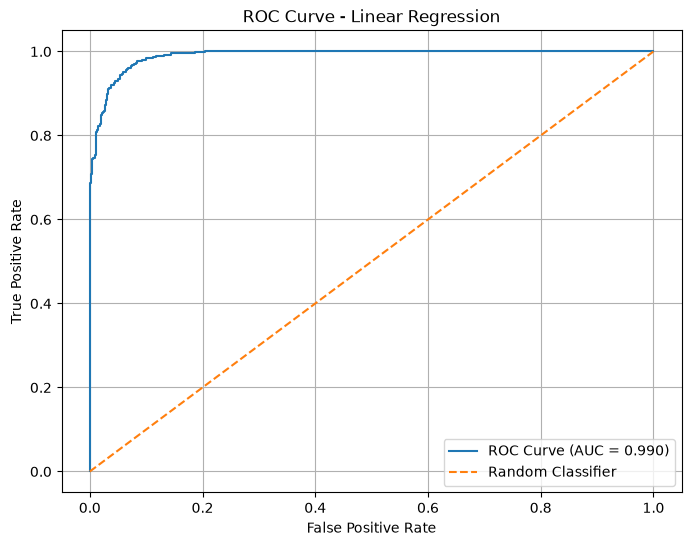

In [41]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Linear Regression"
)

plt.legend()

plt.grid()

plt.show()

#### Conclusion


The Telco Customer Churn dataset was first cleaned by removing the customerID column, converting TotalCharges from object to numeric format, handling missing values and removing duplicate records.

Linear Regression was then applied using tenure and MonthlyCharges as independent variables and TotalCharges as the dependent variable. The model was evaluated using MAE, MSE, RMSE and R².

To perform threshold-based analysis similar to the classification experiment, the median TotalCharges from the training data was selected as the classification threshold. Customers were classified into Low TotalCharges and High TotalCharges categories.

The predicted continuous TotalCharges values from the Linear Regression model were converted into binary classes using this threshold. A confusion matrix was then generated and Accuracy, Precision, Recall, Specificity and F1 Score were calculated.

Finally, the continuous regression predictions were used as scores to generate the ROC curve and calculate the ROC-AUC value.

The regression metrics evaluate how accurately the model predicts the continuous TotalCharges value, while the confusion matrix and ROC curve evaluate the derived High/Low TotalCharges classification. Therefore, the classification results should be interpreted as an additional threshold-based analysis of the regression model rather than as direct Linear Regression metrics.

### **Adding Abnormal**

In [52]:
# Copy the cleaned dataset

normal_data = df_clean.copy()

print("Normal dataset shape:")
print(normal_data.shape)

Normal dataset shape:
(7010, 20)


#### **Creating Abnormal dataset**

In [54]:
# Create abnormal synthetic records

abnormal_data = pd.DataFrame({

    "tenure": [
        2,
        5,
        10,
        15,
        20
    ],

    "MonthlyCharges": [
        50,
        70,
        80,
        90,
        100
    ],

    "TotalCharges": [
        10000,
        15000,
        25000,
        35000,
        50000
    ]
})

print("Abnormal data:")
display(abnormal_data)

Abnormal data:


,tenure,MonthlyCharges,TotalCharges
0,2,50,10000
1,5,70,15000
2,10,80,25000
3,15,90,35000
4,20,100,50000


In [57]:
semantic_data = pd.concat(
    [
        normal_data[
            [
                "tenure",
                "MonthlyCharges",
                "TotalCharges"
            ]
        ],

        abnormal_data
    ],

    ignore_index=True
)

print(
    "Original data:",
    len(normal_data)
)

print(
    "Abnormal records:",
    len(abnormal_data)
)

print(
    "Combined data:",
    len(semantic_data)
)

Original data: 7010
Abnormal records: 5
Combined data: 7015


In [58]:
display(
    semantic_data.tail(
        len(abnormal_data)
    )
)

,tenure,MonthlyCharges,TotalCharges
7010,2,50.0,10000.0
7011,5,70.0,15000.0
7012,10,80.0,25000.0
7013,15,90.0,35000.0
7014,20,100.0,50000.0


In [59]:
X_semantic = semantic_data[
    [
        "tenure",
        "MonthlyCharges"
    ]
]

y_semantic = semantic_data[
    "TotalCharges"
]

In [60]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_semantic,
    y_semantic,
    test_size=0.20,
    random_state=42
)

print(
    "Training size:",
    len(X_train_s)
)

print(
    "Testing size:",
    len(X_test_s)
)

Training size: 5612
Testing size: 1403


In [61]:
semantic_model = LinearRegression()

semantic_model.fit(
    X_train_s,
    y_train_s
)

print(
    "Model trained with abnormal data."
)

Model trained with abnormal data.


In [62]:
y_pred_s = semantic_model.predict(
    X_test_s
)

semantic_predictions = pd.DataFrame({

    "Actual": y_test_s.values,

    "Predicted": y_pred_s

})

display(
    semantic_predictions.head(10)
)

,Actual,Predicted
0,211.95,-757.634654
1,1466.10,1450.849829
2,273.40,835.021440
3,4456.65,4262.043150
4,3958.20,4078.833842
5,520.95,773.163055
6,1441.95,1583.470579
7,1429.65,2683.066022
8,837.50,1151.539103
9,44.00,-519.751087


In [63]:
# Normal model predictions

normal_mae = mean_absolute_error(
    y_test,
    y_pred
)

normal_mse = mean_squared_error(
    y_test,
    y_pred
)

normal_rmse = np.sqrt(
    normal_mse
)

normal_r2 = r2_score(
    y_test,
    y_pred
)


# Abnormal-data model predictions

semantic_mae = mean_absolute_error(
    y_test_s,
    y_pred_s
)

semantic_mse = mean_squared_error(
    y_test_s,
    y_pred_s
)

semantic_rmse = np.sqrt(
    semantic_mse
)

semantic_r2 = r2_score(
    y_test_s,
    y_pred_s
)

In [64]:
comparison = pd.DataFrame({

    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2"
    ],

    "Normal Data": [
        normal_mae,
        normal_mse,
        normal_rmse,
        normal_r2
    ],

    "With Abnormal Data": [
        semantic_mae,
        semantic_mse,
        semantic_rmse,
        semantic_r2
    ]

})

display(
    comparison.round(4)
)

,Metric,Normal Data,With Abnormal Data
0,MAE,590.3626,617.6332
1,MSE,543824.4925,945666.5195
2,RMSE,737.4446,972.4539
3,R2,0.8959,0.8256


In [65]:
semantic_predictions["Error"] = (
    semantic_predictions["Actual"]
    -
    semantic_predictions["Predicted"]
)

semantic_predictions["Absolute_Error"] = (
    abs(
        semantic_predictions["Error"]
    )
)

display(
    semantic_predictions.head(10)
)

,Actual,Predicted,Error,Absolute_Error
0,211.95,-757.634654,969.584654,969.584654
1,1466.10,1450.849829,15.250171,15.250171
2,273.40,835.021440,-561.621440,561.621440
3,4456.65,4262.043150,194.606850,194.606850
4,3958.20,4078.833842,-120.633842,120.633842
5,520.95,773.163055,-252.213055,252.213055
6,1441.95,1583.470579,-141.520579,141.520579
7,1429.65,2683.066022,-1253.416022,1253.416022
8,837.50,1151.539103,-314.039103,314.039103
9,44.00,-519.751087,563.751087,563.751087


In [67]:
error_threshold = (
    semantic_predictions["Absolute_Error"]
    .mean()
    +
    2 *
    semantic_predictions["Absolute_Error"].std()
)

print(
    "Error Threshold:",
    round(error_threshold, 2)
)

semantic_predictions["Abnormal"] = np.where(
    semantic_predictions["Absolute_Error"]
    > error_threshold,
    1,
    0
)

display(
    semantic_predictions.head(10)
)

Error Threshold: 2120.43


,Actual,Predicted,Error,Absolute_Error,Abnormal
0,211.95,-757.634654,969.584654,969.584654,0
1,1466.10,1450.849829,15.250171,15.250171,0
2,273.40,835.021440,-561.621440,561.621440,0
3,4456.65,4262.043150,194.606850,194.606850,0
4,3958.20,4078.833842,-120.633842,120.633842,0
5,520.95,773.163055,-252.213055,252.213055,0
6,1441.95,1583.470579,-141.520579,141.520579,0
7,1429.65,2683.066022,-1253.416022,1253.416022,0
8,837.50,1151.539103,-314.039103,314.039103,0
9,44.00,-519.751087,563.751087,563.751087,0


In [69]:
semantic_data["Actual_Abnormal"] = 0

semantic_data.loc[
    semantic_data.index >= len(normal_data),
    "Actual_Abnormal"
] = 1

print(
    semantic_data["Actual_Abnormal"].value_counts()
)

Actual_Abnormal
0    7010
1       5
Name: count, dtype: int64


In [70]:
X_train_normal = normal_data[
    [
        "tenure",
        "MonthlyCharges"
    ]
]

y_train_normal = normal_data[
    "TotalCharges"
]

In [71]:
abnormal_detection_model = LinearRegression()

abnormal_detection_model.fit(
    X_train_normal,
    y_train_normal
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[65.52,36. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['tenure','MonthlyCharges']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2176
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [72]:
X_abnormal_test = semantic_data[
    [
        "tenure",
        "MonthlyCharges"
    ]
]

y_abnormal_actual = semantic_data[
    "TotalCharges"
]

y_abnormal_pred = abnormal_detection_model.predict(
    X_abnormal_test
)

In [73]:
prediction_error = abs(
    y_abnormal_actual -
    y_abnormal_pred
)

print(
    prediction_error.head()
)

0    1066.021344
1     211.990578
2     214.779351
3     454.002377
4     348.338797
Name: TotalCharges, dtype: float64


In [75]:
predicted_abnormal = (
    prediction_error >
    error_threshold
).astype(int)

actual_abnormal = semantic_data[
    "Actual_Abnormal"
].values

In [77]:
cm_abnormal = confusion_matrix(
    actual_abnormal,
    predicted_abnormal
)

print(
    cm_abnormal
)

[[7010    0]
 [   0    5]]


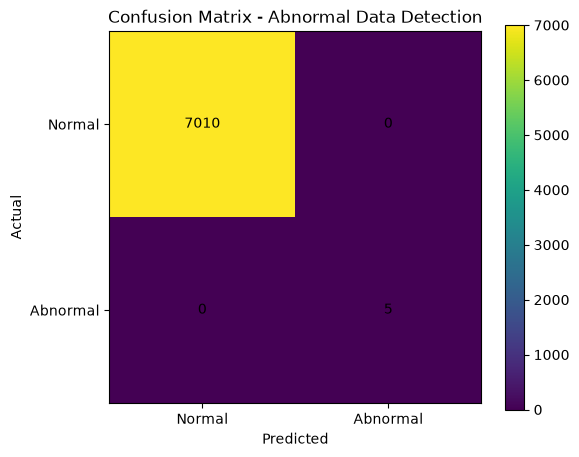

In [82]:
plt.figure(figsize=(6, 5))

plt.imshow(
    cm_abnormal
)

plt.title(
    "Confusion Matrix - Abnormal Data Detection"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0, 1],
    ["Normal", "Abnormal"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Abnormal"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm_abnormal[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

In [83]:
tn, fp, fn, tp = cm_abnormal.ravel()

accuracy = accuracy_score(
    actual_abnormal,
    predicted_abnormal
)

precision = precision_score(
    actual_abnormal,
    predicted_abnormal,
    zero_division=0
)

recall = recall_score(
    actual_abnormal,
    predicted_abnormal,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) != 0
    else 0
)

f1 = f1_score(
    actual_abnormal,
    predicted_abnormal,
    zero_division=0
)

In [84]:
final_abnormal_report = pd.DataFrame({

    "Metric": [
        "TN",
        "FP",
        "FN",
        "TP",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1 Score"
    ],

    "Value": [
        tn,
        fp,
        fn,
        tp,
        accuracy,
        precision,
        recall,
        specificity,
        f1
    ]

})

display(
    final_abnormal_report.round(4)
)

,Metric,Value
0,TN,7010.0
1,FP,0.0
2,FN,0.0
3,TP,5.0
4,Accuracy,1.0
5,Precision,1.0
6,Recall,1.0
7,Specificity,1.0
8,F1 Score,1.0


In [85]:
abnormal_score = prediction_error

In [86]:
fpr, tpr, roc_thresholds = roc_curve(
    actual_abnormal,
    abnormal_score
)

auc_score = roc_auc_score(
    actual_abnormal,
    abnormal_score
)

print(
    "ROC-AUC:",
    round(auc_score, 4)
)

ROC-AUC: 1.0


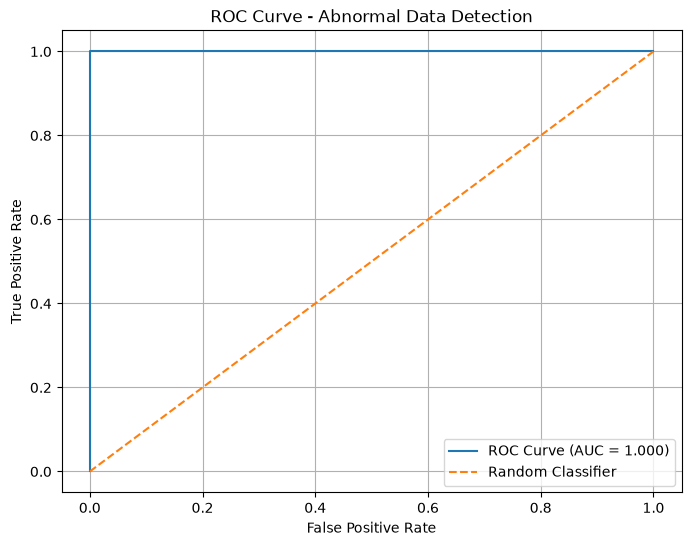

In [87]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Abnormal Data Detection"
)

plt.legend()

plt.grid()

plt.show()